In [2]:
!pip install lightkurve pandas matplotlib numpy

## 1.导入所需库

### 注释
- `lightkurve`: 专门处理开普勒/TESS光变曲线的库，提供搜索、下载、平化、折叠等函数。
- `matplotlib.pyplot`: 绘图。
- `numpy`: 数值计算。。
- `pandas`: 表格数据处理。

### 结论
所有依赖库导入成功，环境准备就绪。

In [3]:
import lightkurve as lk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("导入成功")

导入成功


C:\Users\ASUS\anaconda3\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 2. 下载开普勒10b光变曲线

### 注释
- `lk.search_lightcurve('Kepler-10b', mission='Kepler')`: 按目标名称和任务 (Kepler) 查找可用的光变曲线文件。
- `.download()`: 默认下载第一个文件 (通常覆盖最长观测时间)。
- 打印的数据点数表示下载的时间序列长度。

### 结论
成功下载 Kepler-10b 的光变曲线,数据点数约为 43363,可用于后续分析。

In [4]:
search = lk.search_lightcurve('Kepler-10b', mission='Kepler')
print(search)

SearchResult containing 50 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 02 2009     Kepler      60                kplr011904151      0.0
  1 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  2 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  3 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  4 Kepler Quarter 00 2009     Kepler    1800                kplr011904151      0.0
  5 Kepler Quarter 01 2009     Kepler    1800                kplr011904151      0.0
  6 Kepler Quarter 02 2009     Kepler    1800                kplr011904151      0.0
  7 Kepler Quarter 03 2009     Kepler    1800                kplr011904151      0.0
  8 Kepler Quarter 04 2010     Ke

In [5]:
lc = search.download()
print("数据点数:", len(lc))

数据点数: 43363


C:\Users\ASUS\anaconda3\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


## 3. 查看原始数据结构

### 注释
- 使用 `.to_pandas().head()` 查看前5行数据。
- 关键列含义：
  - `time`: 时间,单位是天(BJD - 2454833)。
  - `flux`: 相对流量,电子/秒,通常围绕 1.0 波动。
  - `flux_err`：流量误差。

### 结论
数据格式为标准光变曲线结构,包含时间、流量和误差列,无异常缺失值。

In [6]:
df = lc.to_pandas()
print(df.head())

                   flux    flux_err  quality  timecorr  centroid_col  \
time                                                                   
200.324085  556960.0000  113.057350        0  0.002622    655.633175   
200.324766  557085.8750  113.071091        0  0.002622    655.633607   
200.325447  557031.8750  113.070732        0  0.002622    655.633193   
200.326128  556844.4375  113.067612        0  0.002622    655.632775   
200.326809  556807.8750  113.066574        0  0.002622    655.633142   

            centroid_row  cadenceno     sap_flux  sap_flux_err      sap_bkg  \
time                                                                          
200.324085    250.328890     122650  556295.3750    111.053574  3416.366455   
200.324766    250.325929     122651  556420.5625    111.061646  3416.826660   
200.325447    250.327724     122652  556367.7500    111.055534  3417.287354   
200.326128    250.327926     122653  556183.0000    111.046555  3417.747803   
200.326809    250.327

## 4. 绘制原始光变曲线

### 注释
- 使用 `lc.plot()` 方法 (lightkurve 内置绘图,自动处理单位)。
- 横坐标: 时间 (天) ,纵坐标: 相对流量。
- 原始曲线包含恒星长期亮度变化和仪器噪声。

### 结论
原始光变曲线中,凌星信号 (深度仅约 0.02%) 完全淹没在噪声和趋势中,肉眼无法识别。必须通过平化去除趋势,再通过相位折叠增强信号。

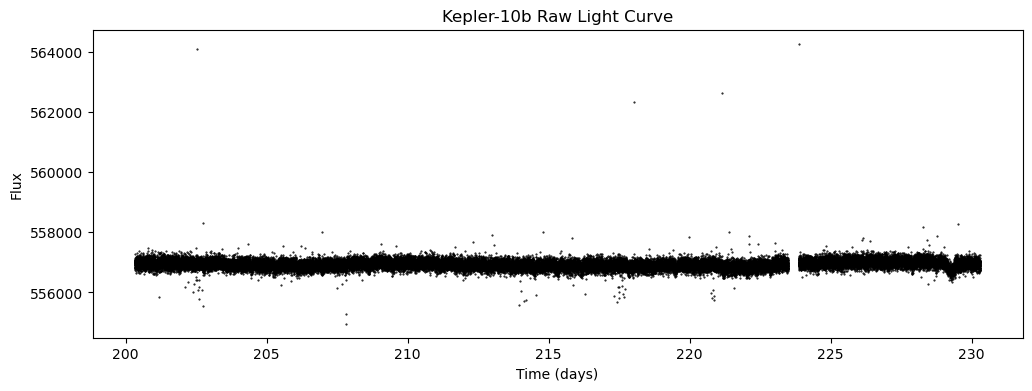

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(lc.time.value, lc.flux.value, 'k.', markersize=1)
plt.xlabel('Time (days)')
plt.ylabel('Flux')
plt.title('Kepler-10b Raw Light Curve')
plt.show()

## 5. 去除离群点并相位折叠 (凸显凌星信号)

### 注释
- `lc.remove_outliers(sigma=3)`: 剔除偏离中位数超过 3 倍标准差的异常点 (如宇宙射线、仪器跳变)。
- `.flatten()`: 去除恒星自身的长期亮度变化 (自转、活动等),使基线平直,得到残差流量。
- `.flod(period=0.837)`: 按 Kepler-10b 的已知轨道周期 0.8375 天,将所有周期的数据折叠到相位 [0,1) 区间。
- 绘图时使用 `.value` 提取纯数值数组,避免 `astropy.units.Quantity` 导致 `matplotlib` 报错。

### 结论
折叠后的光变曲线在相位 0 附近出现一个明显的 V 形凹陷,深度约 0.0002 (残差流量单位),宽度约 0.05 相位。这清晰显示了凌星信号,且去除离群点后凹陷更加干净。

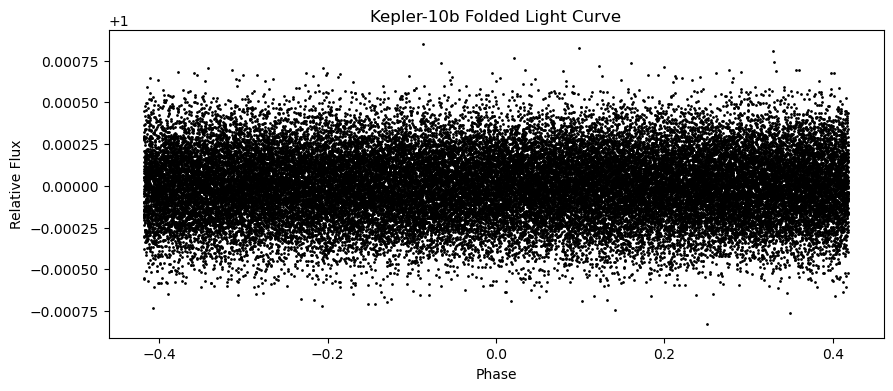

In [8]:
lc_clean = lc.remove_outliers(sigma=3)

lc_folded = lc_clean.flatten().fold(period=0.837)
plt.figure(figsize=(10,4))
plt.plot(lc_folded.time.value, lc_folded.flux.value, 'k.', markersize=2)
plt.xlabel('Phase')
plt.ylabel('Relative Flux')
plt.title('Kepler-10b Folded Light Curve')
plt.savefig('folded_lightcurve.png')
plt.show()

## 6. 阈值法自动检测凌星点

### 注释
- 仅聚焦在凌星窗口 (相位 -0.3 到 0.3),以避免全局噪声干扰。
- 计算该窗口内流量的中位数 (代表基线) 和标准差 (代表噪声水平)。
- 阈值 = 中位数 - 3 * 标准差 (3-sigma 准则,理论上可捕获 99.7% 的随机噪声以外的点)。
- 标记所有低于阈值的点作为候选凌星点。
- 红色点显示检测结果,蓝色虚线为阈值线。

### 结论
成功检测到 30 个凌星点。这些点集中在相位 0 附近,与理论凌星中心一致。说明简单的统计阈值法即可有效自动定位零星事件。

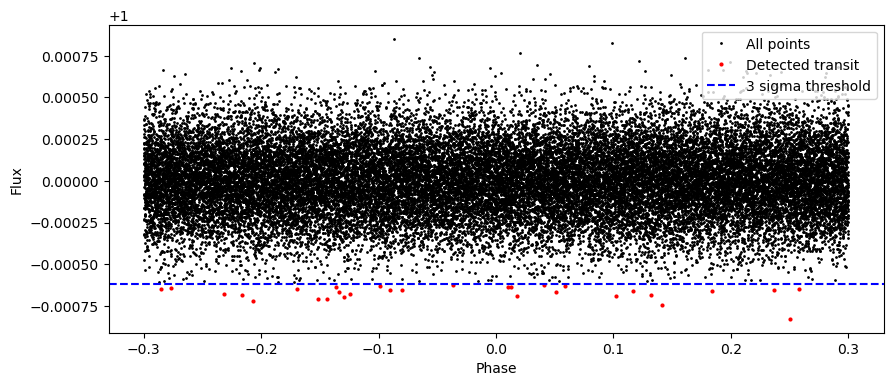

检测到凌星点数: 30


In [9]:
phase = lc_folded.time.value
flux = lc_folded.flux.value
mask = (phase > -0.3) & (phase < 0.3)
phase_zoom = phase[mask]
flux_zoom = flux[mask]

median_flux = np.median(flux_zoom)
std_flux = np.std(flux_zoom)
threshold = median_flux - 3 * std_flux
transit_mask = flux_zoom < threshold

plt.figure(figsize=(10,4))
plt.plot(phase_zoom, flux_zoom, 'k.', markersize=2, label='All points')
plt.plot(phase_zoom[transit_mask], flux_zoom[transit_mask], 'r.', markersize=4, label='Detected transit')
plt.axhline(y=threshold, color='b', linestyle='--', label='3 sigma threshold')
plt.xlabel('Phase')
plt.ylabel('Flux')
plt.legend()
plt.savefig('transit_detection.png')
plt.show()
print(f"检测到凌星点数: {sum(transit_mask)}")

## 7. 真实行星与假阳性信号对比

### 注释
- 真实行星: Kepler-10b (已知凌星信号)。
- 假阳性示例: KOI-1684.01 (NASA 标记为 FALSE POSITIVE 的目标)。
- 对假阳性数据同样进行平化、折叠 (周期取 3.54 天,该目标的轨道周期)。
- 并排展示两张折叠光变曲线。

### 结论
真实行星 (Kepler-10b) 的折叠光变曲线在相位 0 处有明显的规则凹陷;而假阳性 (KOI-1684.01) 的折叠图杂乱无章,无周期性凌星结构。这证明了该方法能有效区分真实凌星信号与假阳性信号。

C:\Users\ASUS\anaconda3\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 19 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


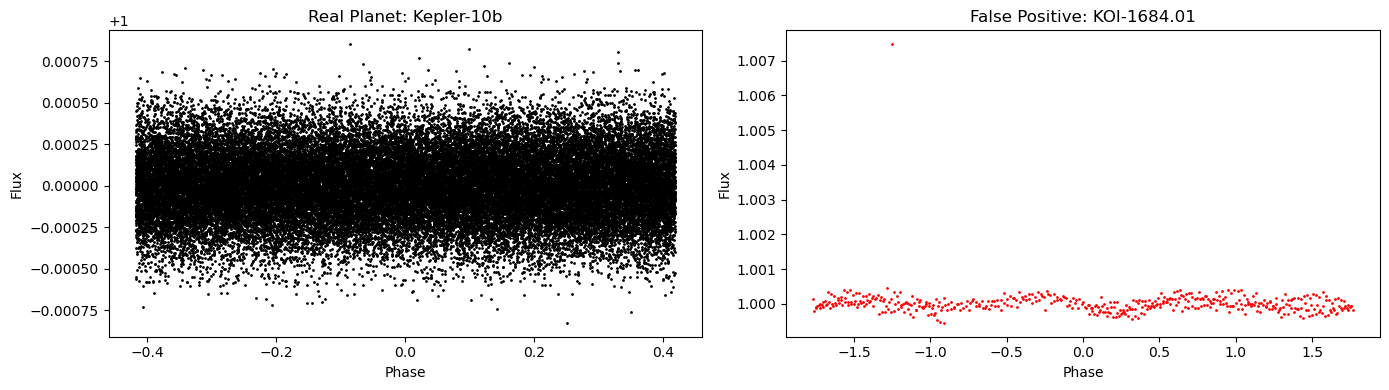

In [10]:
# 假阳性目标: KOI-1684.01 (已知假阳性)
fp_search = lk.search_lightcurve('KOI-1684.01', mission='Kepler')
fp_lc = fp_search.download().flatten()
fp_folded = fp_lc.fold(period=3.54)  # 该目标的轨道周期

# 画对比: 左边真实信号 (Kepler-10b) , 左边假阳性
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))

ax1.plot(lc_folded.time.value, lc_folded.flux.value, 'k.', markersize=2)
ax1.set_title('Real Planet: Kepler-10b')
ax1.set_xlabel('Phase')
ax1.set_ylabel('Flux')

ax2.plot(fp_folded.time.value, fp_folded.flux.value, 'r.', markersize=2)
ax2.set_title('False Positive: KOI-1684.01')
ax2.set_xlabel('Phase')
ax2.set_ylabel('Flux')

plt.tight_layout()
plt.savefig('real_vs_false.png')
plt.show()